<a href="https://colab.research.google.com/github/gnn59lll-coder/Laboratory-works-for-II/blob/main/%D0%9B%D0%B0%D0%B1%D0%B0_2_%D0%9A%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
# Импортируем библиотеки

import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [103]:
# Загрузка данных из CSV-файла
das = pd.read_csv('/content/sample_data/data_about_students.csv', sep=';')

In [104]:
print("Первые 7 строк датасета:")
das.head(7)

Первые 7 строк датасета:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,2,39,1,9991,0,19,133.1,1,37,37,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,1,1,1,9500,1,1,142.0,1,19,38,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate


## Названия столбцов:
Marital status (Семейное положение)

Application mode (Способ подачи заявления)

Application order (Очередность заявления)

Course (Номер учебной программы)

Daytime/evening attendance (Посещаемость: дневная/вечерняя(заочная))

Previous qualification (Предыдущая квалификация)

Previous qualification (grade) (Оценка за предыдущую квалификацию)

Nacionality (Национальность)

Mother's qualification (Образование матери)

Father's qualification (Образование отца)

Mother's occupation (Профессия матери)

Father's occupation (Профессия отца)

Admission grade (Проходной балл на поступление в вуз)

Displaced (Перемещенное лицо(беженец или переселенец))

Educational special needs (Особые образовательные потребности)

Debtor (Должен ли за обучение)

Tuition fees up to date (Актуальность оплаты обучения)

Gender (Пол)

Scholarship holder (Получатель стипендии)

Age at enrollment (Возраст на момент зачисления)

International (Иностранный студент)

Curricular units 1st sem (credited) / Curricular units 2nd sem (credited) (Количество учебных дисциплин, которые были зачтены студенту в начале семестра ).

Curricular units 1st sem (enrolled) / Curricular units 2nd sem (enrolled) (Количество учебных дисциплин, на которые студент официально записался в данном семестре.)

Curricular units 1st sem (evaluations) / Curricular units 2nd sem (evaluations) ( Общее количество оценок или аттестаций, полученных студентом в течение семестра.)

Curricular units 1st sem (approved) / Curricular units 2nd sem (approved) ( Количество дисциплин, которые студент успешно сдал в семестре.)

Curricular units 1st sem (grade) / Curricular units 2nd sem (grade) (Средний балл студента по всем сданным дисциплинам за семестр.)

Curricular units 1st sem (without evaluations) / Curricular units 2nd sem (without evaluations) ( Количество дисциплин, по которым студент не был аттестован.)

Unemployment rate (Уровень безработицы)

Inflation rate (Уровень инфляции)

GDP (ВВП)

Target (Статус студента на момент сбора данных.)

Dropout — студент отчислен.

Graduate — студент успешно закончил обучение.

Enrolled — студент все еще учится.

##Анализ данных

In [105]:
# размер датасета, 4424 записей, 37 столбцов

das.shape

(4424, 37)

In [106]:
# отображаем первые 10 строк датасета

das.head(10)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,2,39,1,9991,0,19,133.1,1,37,37,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,1,1,1,9500,1,1,142.0,1,19,38,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,1,18,4,9254,1,1,119.0,1,37,37,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,1,1,3,9238,1,1,137.0,62,1,1,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,1,1,1,9238,1,1,138.0,1,1,19,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout


In [107]:
import mpl_toolkits.mplot3d  # noqa: F401


from sklearn import datasets
from sklearn.cluster import KMeans

In [108]:
print("="*50)
print("ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("="*50)
das.info()

ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qual

In [109]:
das.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [110]:
das['Target'].unique()

array(['Dropout', 'Graduate', 'Enrolled'], dtype=object)

In [111]:
# Теперь проверим количество строк, которое принадлежит каждой Target:

das['Target'].value_counts()

,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


In [112]:
das['Target'].describe()

,Target
count,4424
unique,3
top,Graduate
freq,2209


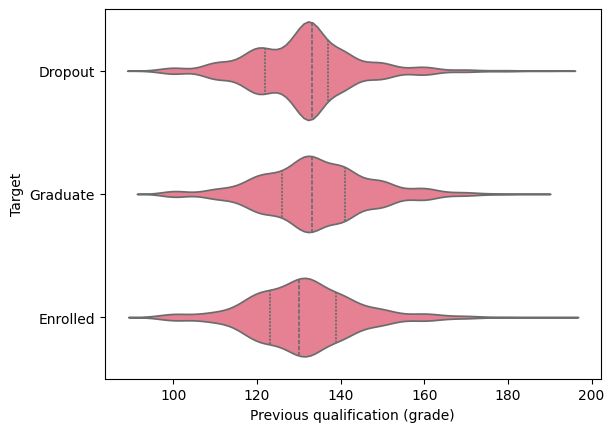

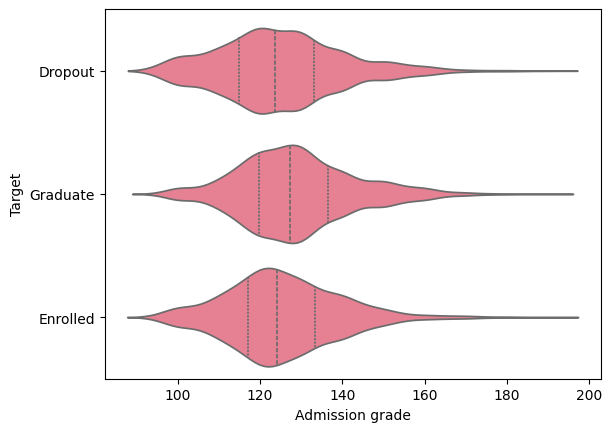

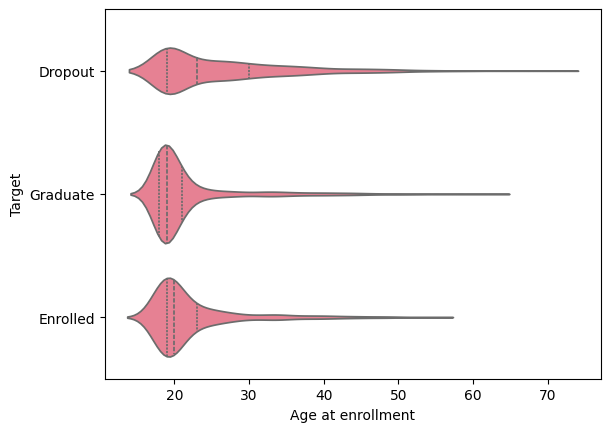

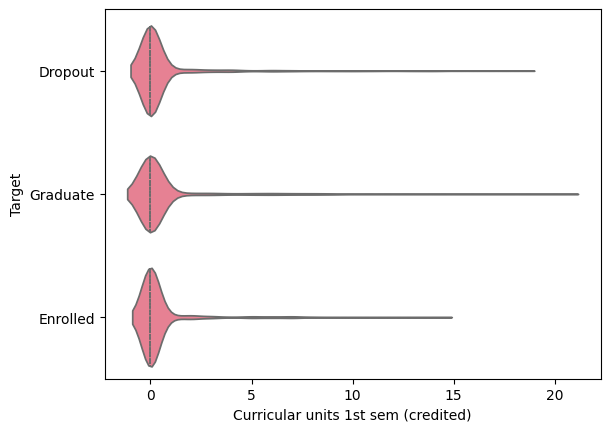

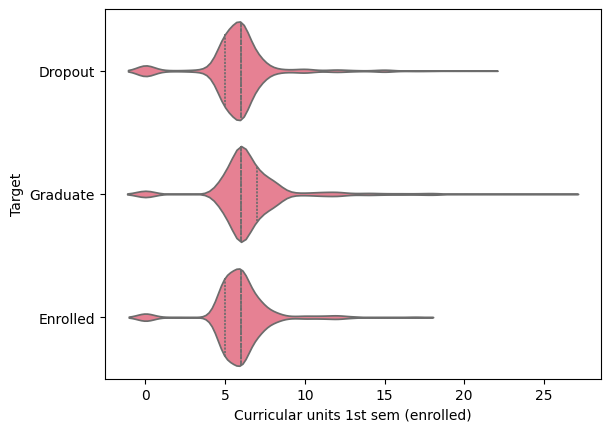

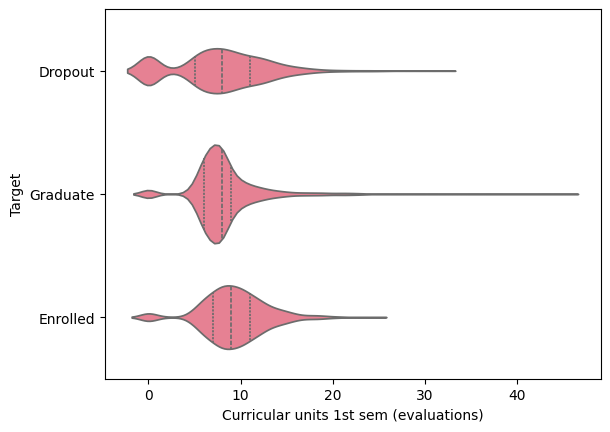

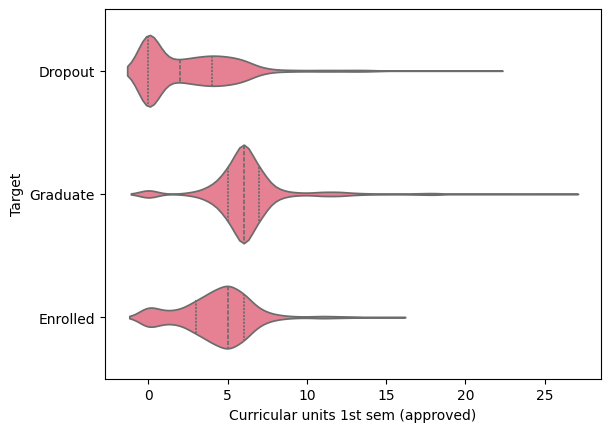

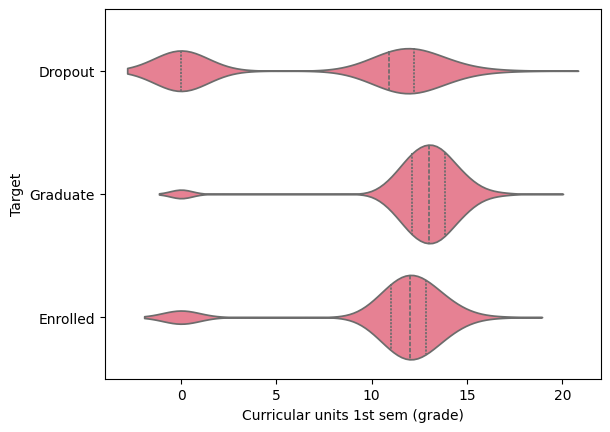

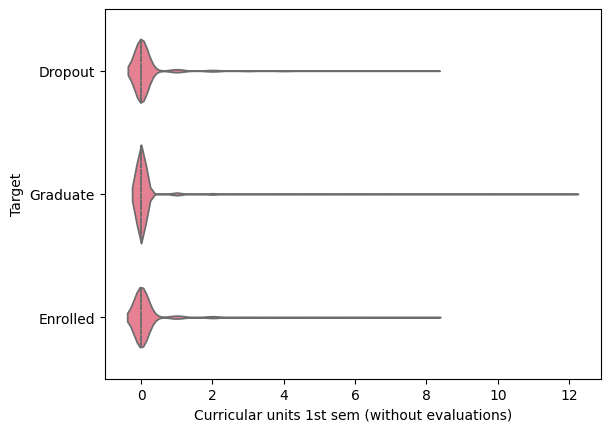

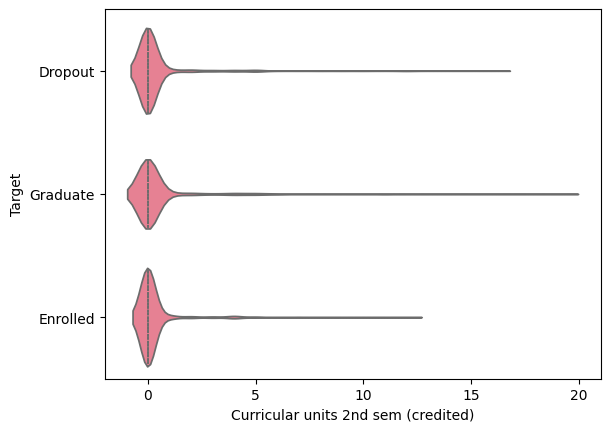

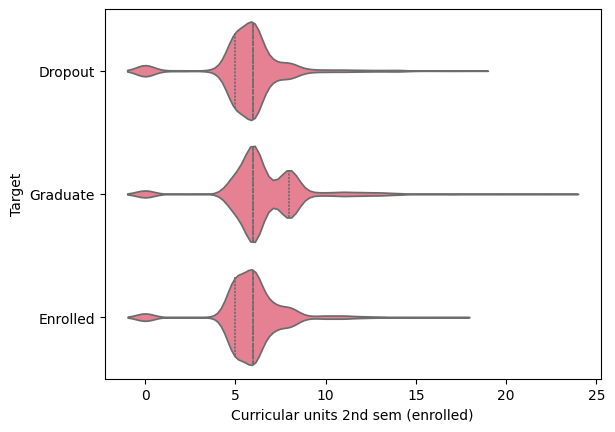

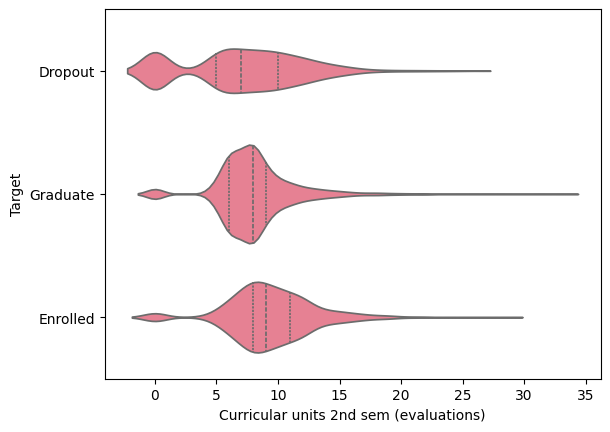

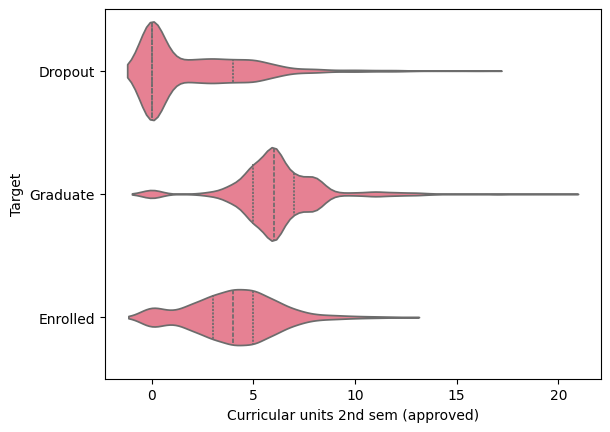

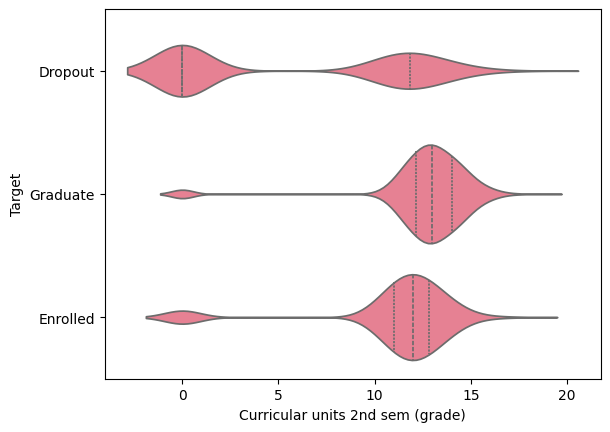

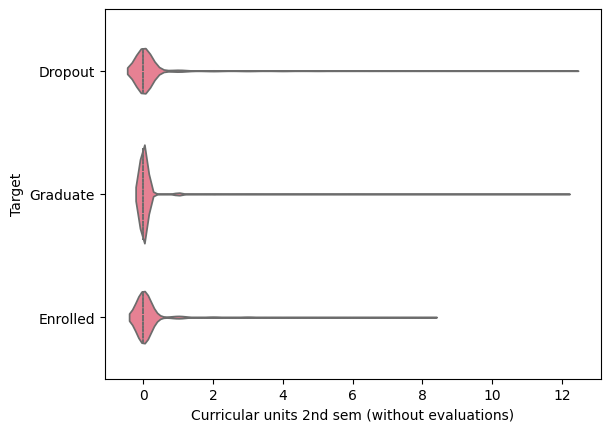

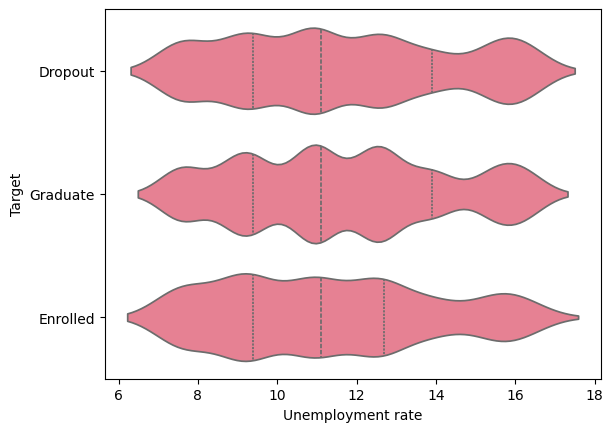

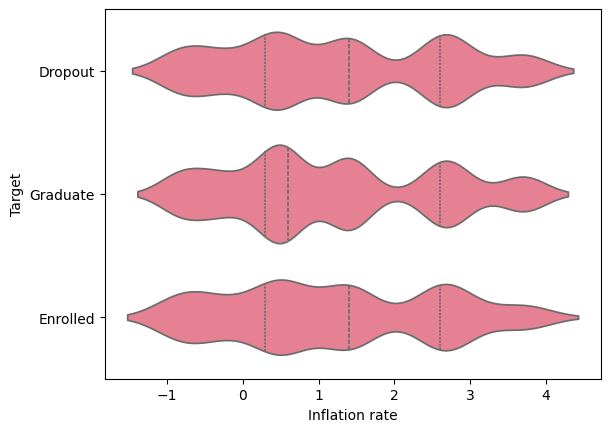

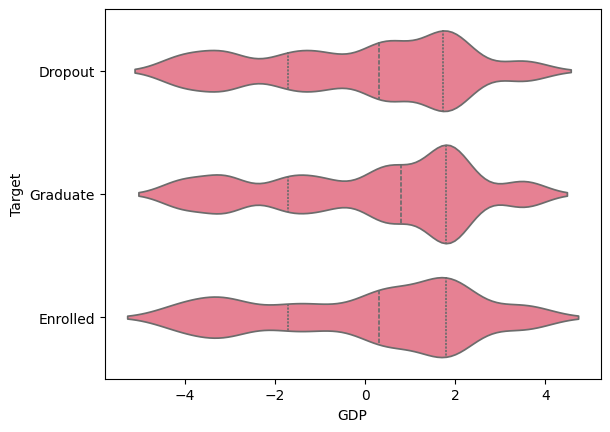

In [113]:
sns.violinplot(y='Target', x='Previous qualification (grade)', data=das, inner='quartile')
plt.show()
sns.violinplot(y='Target', x='Admission grade', data=das, inner='quartile')
plt.show()
sns.violinplot(y='Target', x='Age at enrollment', data=das, inner='quartile')
plt.show()
sns.violinplot(y='Target', x='Curricular units 1st sem (credited)', data=das, inner='quartile')
plt.show()
sns.violinplot(y='Target', x='Curricular units 1st sem (enrolled)', data=das, inner='quartile')
plt.show()
sns.violinplot(y='Target', x='Curricular units 1st sem (evaluations)', data=das, inner='quartile')
plt.show()
sns.violinplot(y='Target', x='Curricular units 1st sem (approved)', data=das, inner='quartile')
plt.show()
sns.violinplot(y='Target', x='Curricular units 1st sem (grade)', data=das, inner='quartile')
plt.show()
sns.violinplot(y='Target', x='Curricular units 1st sem (without evaluations)', data=das, inner='quartile')
plt.show()
sns.violinplot(y='Target', x='Curricular units 2nd sem (credited)', data=das, inner='quartile')
plt.show()
sns.violinplot(y='Target', x='Curricular units 2nd sem (enrolled)', data=das, inner='quartile')
plt.show()
sns.violinplot(y='Target', x='Curricular units 2nd sem (evaluations)', data=das, inner='quartile')
plt.show()
sns.violinplot(y='Target', x='Curricular units 2nd sem (approved)', data=das, inner='quartile')
plt.show()
sns.violinplot(y='Target', x='Curricular units 2nd sem (grade)', data=das, inner='quartile')
plt.show()
sns.violinplot(y='Target', x='Curricular units 2nd sem (without evaluations)', data=das, inner='quartile')
plt.show()
sns.violinplot(y='Target', x='Unemployment rate', data=das, inner='quartile')
plt.show()
sns.violinplot(y='Target', x='Inflation rate', data=das, inner='quartile')
plt.show()
sns.violinplot(y='Target', x='GDP', data=das, inner='quartile')
plt.show()

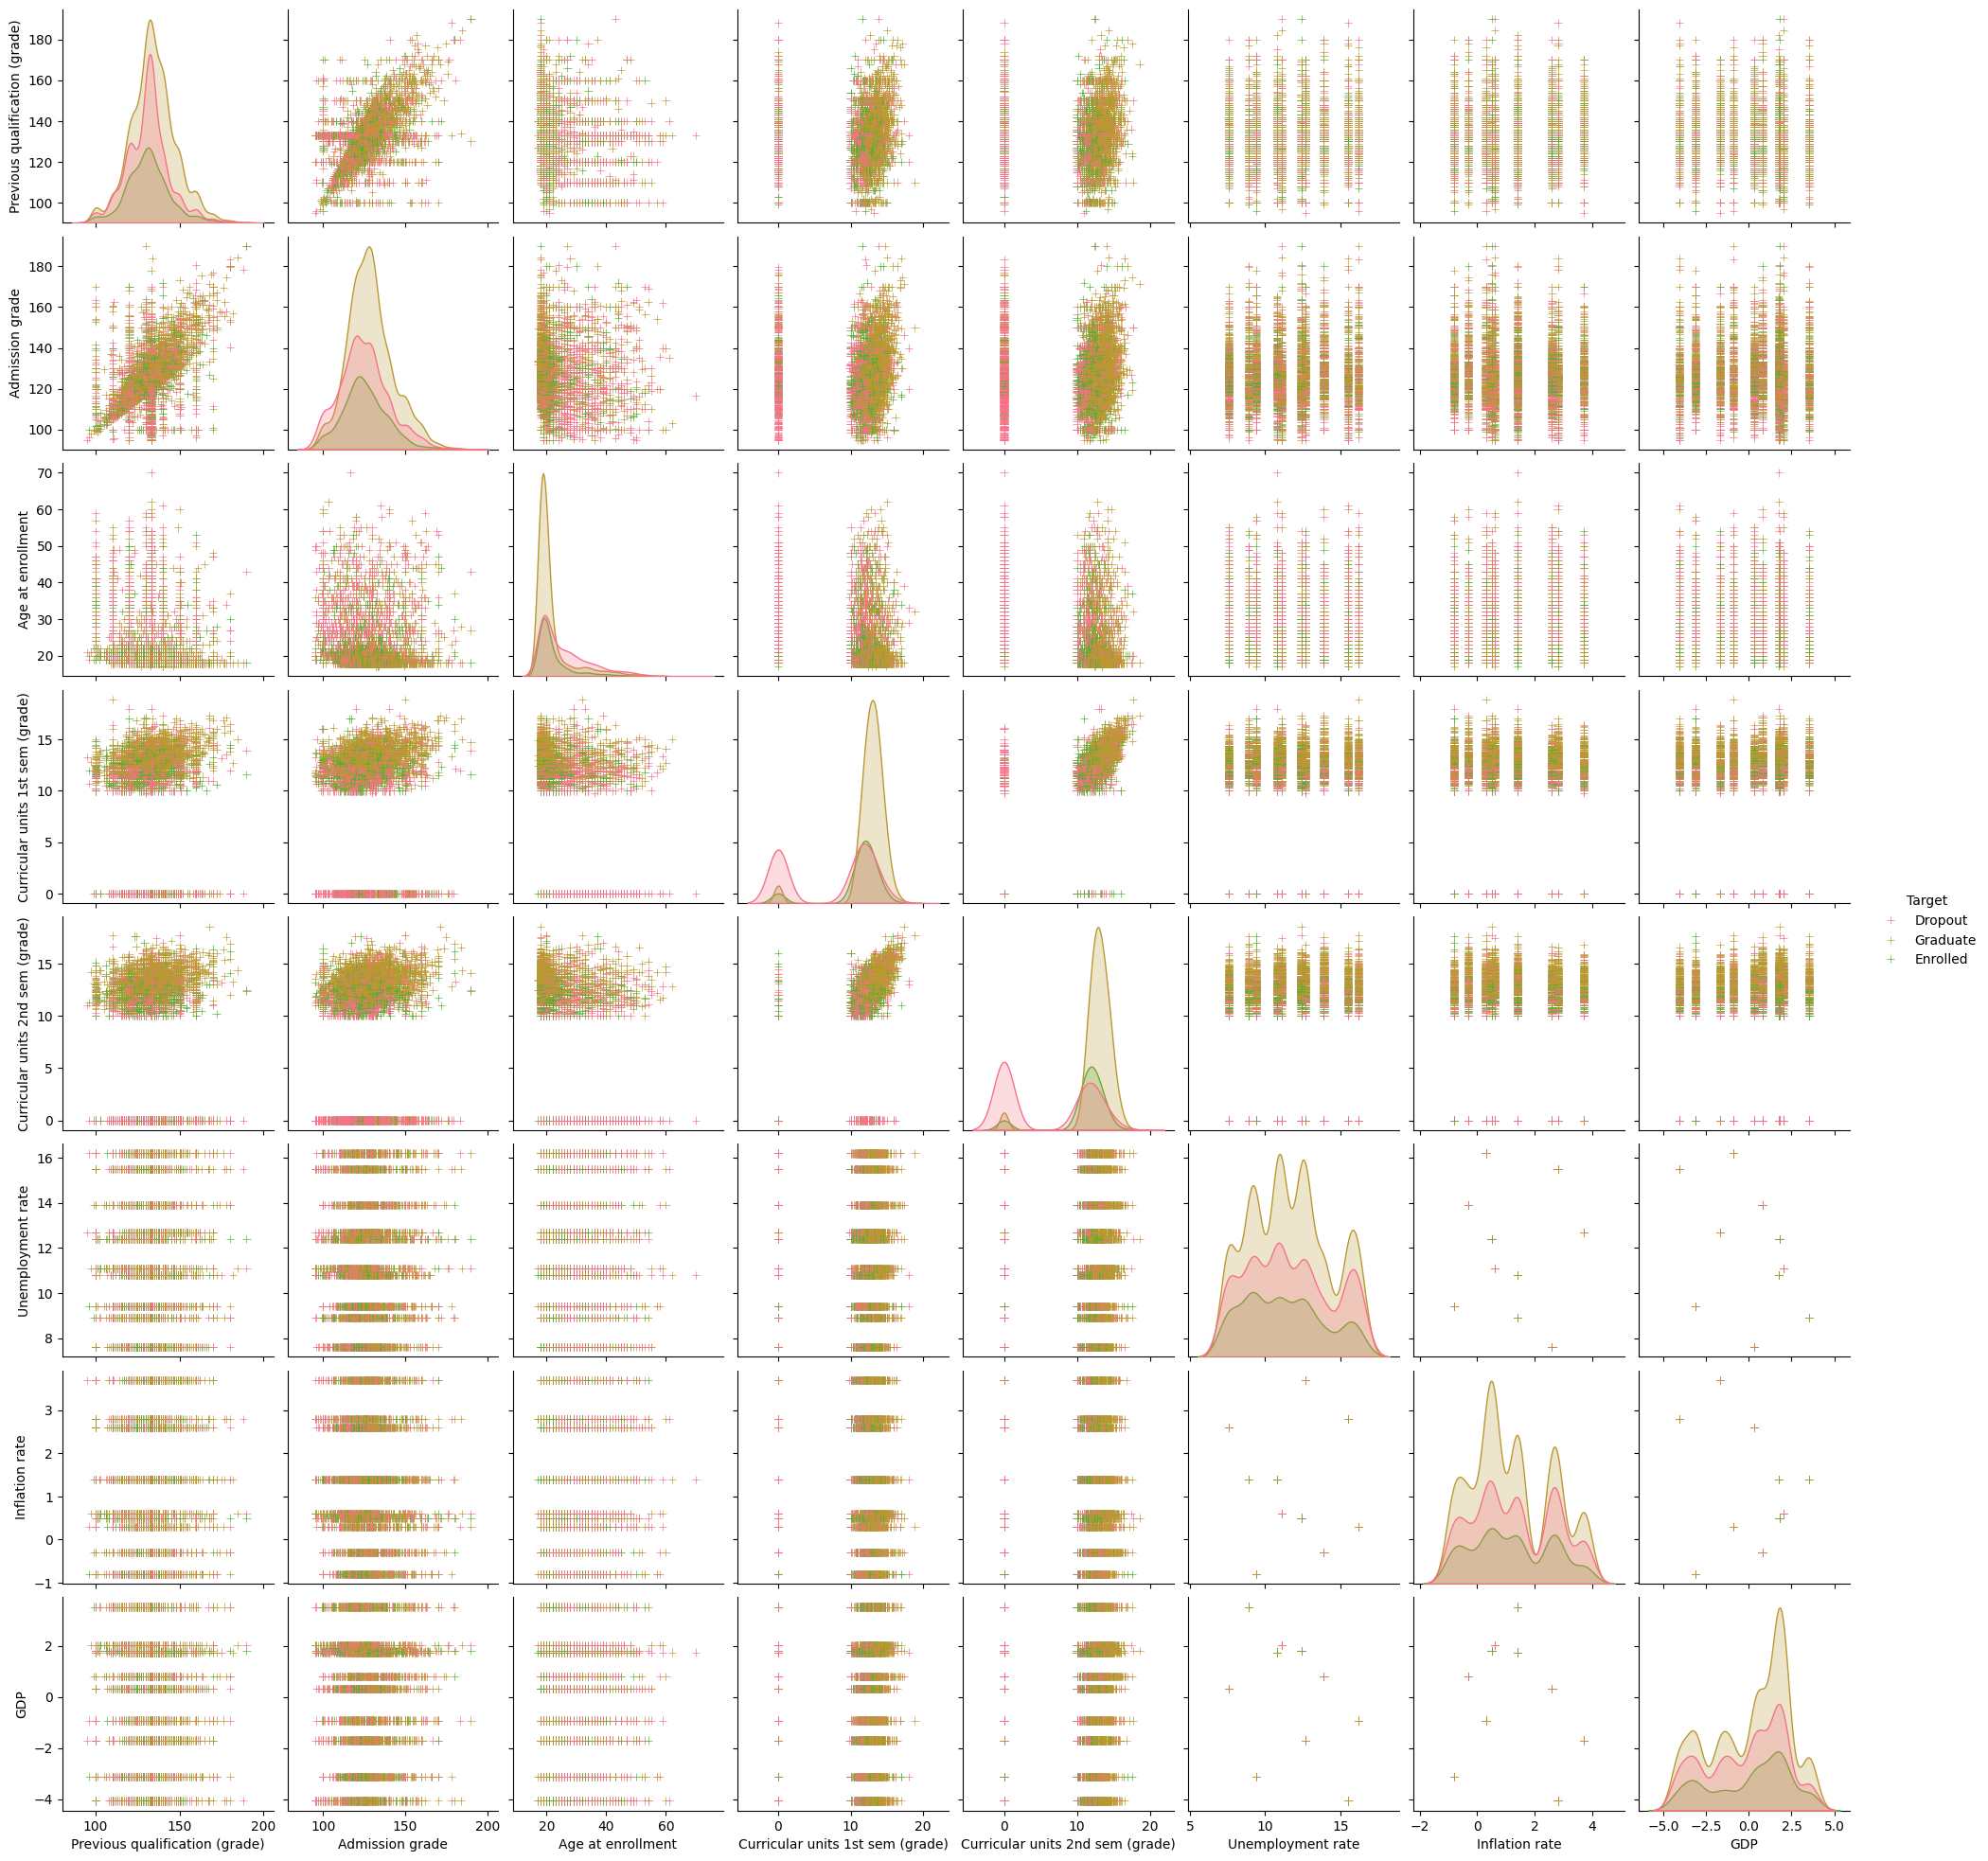

In [114]:
#Парный график
#Построение нескольких попарных двумерных распределений в наборе данных с помощью pairplot(Выбраны только некоторые столбцы. А то получалась картина 1225 неотображаемых графиков):

selected_cols = [
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]
sns.pairplot(das[selected_cols + ['Target']], hue='Target', markers='+')
plt.show()

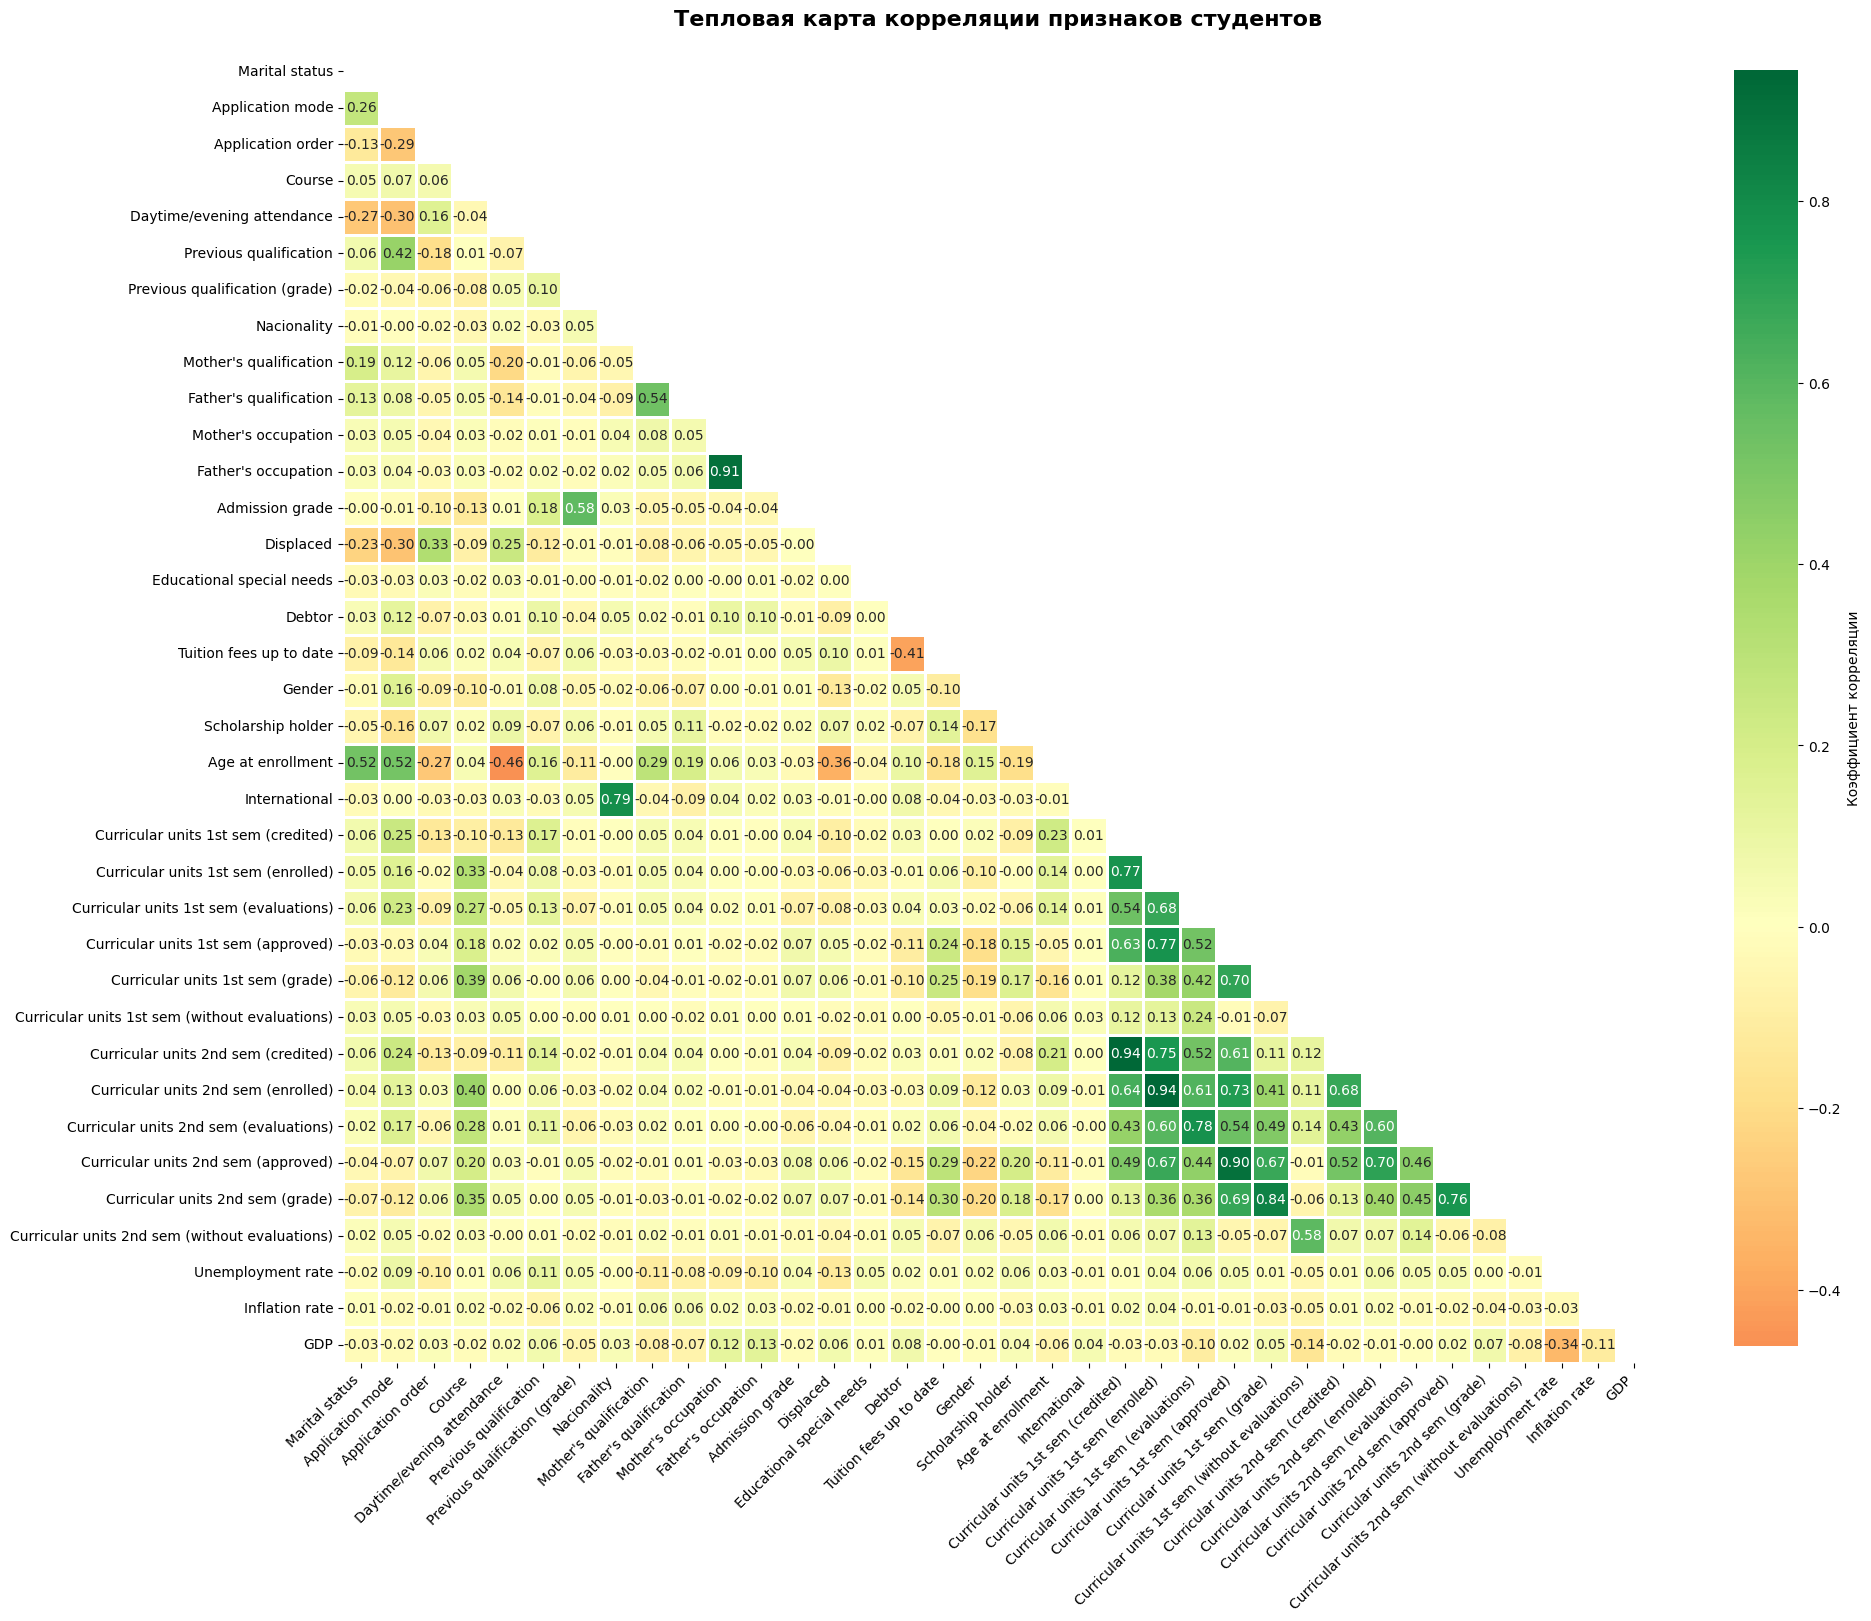

In [115]:
#Построение тепловой карты для проверки корреляции.
plt.figure(figsize=(20, 18))
correlation_matrix = das.corr(numeric_only=True)
# Создаем маску для верхнего треугольника
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
# Тепловая карта с подписями
sns.heatmap(correlation_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=.8,
    cbar_kws={"shrink": .8, "label": "Коэффициент корреляции"},
    annot_kws={"size": 10})

plt.title('Тепловая карта корреляции признаков студентов',
    fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


##Построение модели
Разделение набора данных Y - целевая переменная, которую предсказываем. Мы ищем зависимость этой переменной от соответствующих фич.

В X складываем весь набор данных без целевой переменной.

In [116]:
from sklearn.preprocessing import OrdinalEncoder
#Преобразую Target из категориального в числовой признак
y_mapped = OrdinalEncoder()
das[['Target']] = y_mapped.fit_transform(das[['Target']])
das.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0.0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2.0
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0.0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2.0
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2.0


In [117]:
#Нарекаю все признаки, кроме Target - X, и нарекаю Target - Y.
X = das.drop(['Target'], axis=1)
y = das['Target']
print(f'X shape: {X.shape} | y shape: {y.shape} ')

X shape: (4424, 36) | y shape: (4424,) 


X имеет 4424 строк и 36 столбцов, тогда как Y имеет 4424 строк и только один столбец.

#### Train Test разделение

Разделяем наш набор данных на обучающий (train) и тестовый (test) с помощью train_test_split(), мы берем 80% данных для обучения нашей модели и 20% оставляем в качестве проверочного набора данных:

**Рассмотрим столбец Target:**

In [154]:
import scipy.stats as stats
y_mapped = y.map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=15)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=True)
stats.ttest_ind (a=y_train, b=y_test)

TtestResult(statistic=np.float64(-0.6077423237647833), pvalue=np.float64(0.5433895962755715), df=np.float64(4422.0))

## Обучение и выбор оптимальной модели

Далее попробуем следующие алгоритмы:

Logistic Regression (LR) </br>
Linear Discriminant Analysis (LDA)</br>
K-Nearest Neighbors (KNN)</br>
Classification and Regression Trees (CART)</br>
Gaussian Naive Bayes (NB)</br>
Support Vector Machines (SVM)</br>

In [158]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split


In [160]:
# создаем лист для тех моделей, которые будем изучать
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVC', SVC(gamma='auto')))

# оцениваем их метрики
results = []
model_names = []
for name, model in models:
  kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
  cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
  results.append(cv_results)
  model_names.append(name)
  print(f'{name}: {cv_results.mean():.4f} (±{cv_results.std():.4f})')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

LR: 0.7327 (±0.0203)
LDA: 0.7649 (±0.0177)
KNN: 0.5880 (±0.0168)
CART: 0.6762 (±0.0202)
NB: 0.6832 (±0.0248)
SVC: 0.4979 (±0.0039)


LDA показала лучший результат - 76.5%. Далее работаем с LinearDiscriminantAnalysis.

Давайте обучим модель LDA на нашем обучающем наборе и сделаем прогноз на тестовом наборе на следующем шаге.

Обучение конкретной модели
Определяем нашу модель LDA После этого подгоняем/обучаем модель на X_train и Y_train с помощью метода .fit(). Затем мы делаем прогноз на X_test с помощью метода .predict().

In [164]:
sk_lda = LinearDiscriminantAnalysis(solver='eigen')
sk_lda.fit(X_train, y_train)
sk_lda_pred_res = sk_lda.predict(X_test)
sk_transformed = sk_lda.transform(X_train)
sk_lda_accuracy = accuracy_score(y_test, sk_lda_pred_res)

print(f'sk LDA accuracy: {sk_lda_accuracy}')
print(f'sk LDA prediction: {sk_lda_pred_res}')
print('sk transformed features', sk_transformed[:5].T, sep='\n')

sk LDA accuracy: 0.7299435028248588
sk LDA prediction: [2. 2. 1. 2. 0. 1. 2. 2. 0. 2. 2. 2. 1. 2. 2. 2. 0. 0. 2. 2. 2. 0. 0. 2.
 2. 0. 0. 2. 0. 2. 2. 1. 2. 0. 2. 1. 2. 2. 0. 1. 2. 0. 0. 2. 2. 2. 2. 0.
 2. 1. 0. 2. 2. 2. 2. 2. 0. 2. 2. 2. 0. 0. 1. 2. 0. 0. 1. 2. 2. 2. 2. 1.
 2. 0. 2. 2. 2. 1. 2. 2. 1. 0. 0. 0. 2. 0. 2. 2. 2. 0. 2. 0. 2. 2. 2. 1.
 0. 0. 0. 1. 0. 2. 0. 2. 2. 2. 2. 0. 0. 2. 0. 2. 2. 2. 2. 2. 2. 1. 1. 2.
 1. 2. 0. 1. 2. 2. 1. 2. 2. 2. 2. 2. 0. 2. 2. 0. 2. 2. 2. 2. 2. 2. 0. 1.
 0. 1. 2. 2. 2. 0. 1. 0. 1. 0. 2. 0. 2. 0. 0. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 0. 2. 2. 1. 1. 0. 2. 0. 2. 0. 1. 2. 0. 2. 0. 2. 1. 2. 2. 1. 2. 2. 0. 2.
 2. 2. 2. 2. 2. 2. 1. 2. 2. 0. 2. 1. 2. 2. 2. 2. 0. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 0. 1. 2. 2. 2. 1. 2. 2. 2. 1. 2. 2. 2. 2. 0. 0. 2. 2. 2.
 2. 2. 2. 2. 0. 0. 2. 2. 0. 2. 2. 0. 0. 1. 2. 0. 1. 0. 0. 2. 2. 0. 2. 0.
 0. 1. 2. 0. 1. 0. 2. 0. 1. 1. 2. 2. 1. 2. 2. 2. 2. 0. 0. 2. 0. 2. 0. 0.
 2. 1. 0. 2. 0. 2. 2. 0. 0. 2. 1. 2. 2. 2. 2. 0. 2. 2. 0. 2. 2. 2. 0.

In [165]:
das.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

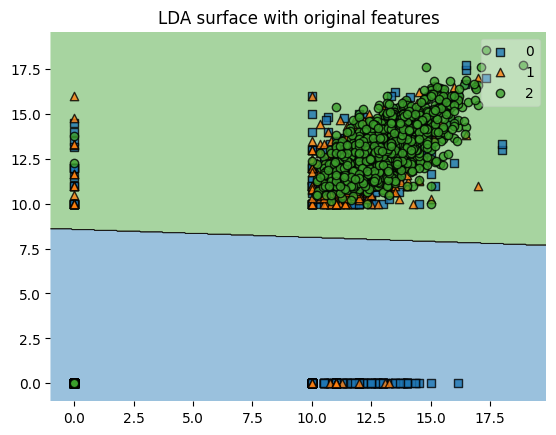

In [168]:
from mlxtend.plotting import plot_decision_regions
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import numpy as np

#y_s = y.map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})
# Создадим целевой вектор
y_s = y_train  # Target
X_2d = X_train[['Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']].values
# Преобразуем y в целые числа (классы)
y_2d = y_s.values.astype(np.int_)

# Создаём и обучаем модель
sk_lda1 = LinearDiscriminantAnalysis(solver='eigen')
sk_lda1.fit(X_2d, y_2d)
# Построение графика
plt.title('LDA surface with original features')
plot_decision_regions(
    X=X_2d,
    y=y_2d,
    clf=sk_lda1
)
plt.show()

LinearDiscriminantAnalysis(solver='eigen')


<Axes: title={'center': 'LDA surface with transformed features'}>

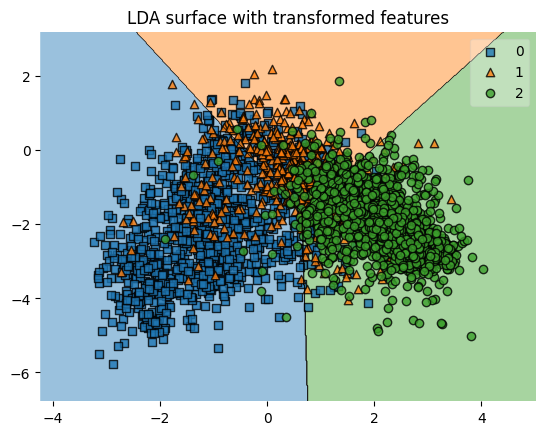

In [170]:
Xs = das[['Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']]
ys = das['Target'].values.astype(np.int_)

sk_lda2 = LinearDiscriminantAnalysis(solver='eigen')
X1_lda = sk_lda2.fit(X, ys).transform(X)
print(sk_lda2)
Xs = X1_lda

X1_lda_train, X1_lda_test, y1_train, y1_test = train_test_split(X1_lda, ys, random_state=0)

sk_lda2.fit(X1_lda_train, y1_train)

plt.title('LDA surface with transformed features')
plot_decision_regions(X=X1_lda, y=ys, clf=sk_lda2)

In [171]:
predicted = sk_lda1.predict(X1_lda_test)

In [173]:
from sklearn import metrics
import numpy as np

# Предсказание на тестовой выборке
from sklearn.linear_model import LogisticRegression

# Обучаем модель
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

# Предсказываем
predicted = model.predict(X_test)

# Метрики
accuracy = metrics.accuracy_score(y_test, predicted)
recall = metrics.recall_score(y_test, predicted, average="weighted")
precision = metrics.precision_score(y_test, predicted, average="weighted")

print("Accuracy:", round(accuracy, 2))
print("Recall (all 1s predicted right):", round(recall, 2))
print("Precision (confidence when predicting a 1):", round(precision, 2))
print("\nDetail:")
print(metrics.classification_report(
    y_test,
    predicted,
    target_names=['Dropout', 'Enrolled', 'Graduate']
))

Accuracy: 0.68
Recall (all 1s predicted right): 0.68
Precision (confidence when predicting a 1): 0.72

Detail:
              precision    recall  f1-score   support

     Dropout       0.77      0.60      0.68       278
    Enrolled       0.35      0.56      0.43       157
    Graduate       0.83      0.77      0.80       450

    accuracy                           0.68       885
   macro avg       0.65      0.64      0.64       885
weighted avg       0.72      0.68      0.69       885



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
